# Macro Data - Linear State-Space Models

This notebook fits linear Gaussian state-space models (LG-SSMs) to US macroeconomic data from FRED
and compares filtering/smoothing performance across model specifications.

Models (in increasing complexity):
1. **Simple LG-SSM** — 1D latent state, 1D observation (GDP growth). Suffers from weak-identifiability of `alpha`; fix `alpha = 1`.
2. **Multivariate Observation LG-SSM** — 1D latent "business cycle" state, K=3 quarterly observations (GDP growth, IP growth, −ΔUR). Identification via reference series (`alpha_1 ≡ 1`).
3. **Macro LG-SSM (HLW)** — Structural macro model with 8D latent state (output gap, trend growth, NAIRU, neutral rate, and lags) and 4 observed series (GDP growth, inflation, unemployment, federal funds rate). See `src/models/linear_macro.py`.
4. *(Extra)* **Free multivariate LG-SSM** — Obs and latent dims specified, but all entries of `A`, `C`, intercepts left free. Will likely suffer from weak-identifiability.

## Description of the Models

### Simple LG-SSM

$$
\begin{align}
& x_t = \phi x_{t-1} + \epsilon_t,
&& \epsilon_t \sim N(0, \sigma^2) \\
& y_t = \alpha x_t + \nu_t,
&& \nu_t \sim N(0,\tau^2)
\end{align}
$$

Parameterized by $\theta = (\phi, \sigma^2, \tau^2)$ with $\alpha \equiv 1$ fixed.

**Weak-identifiability:** Without fixing $\alpha$, the likelihood is invariant under the scaling $(x_t, \alpha) \mapsto (x_t / c, \alpha c)$ for any $c > 0$. Fixing $\alpha = 1$ resolves this. Note that even with $\alpha = 1$, $\sigma^2$ and $\tau^2$ are separately identified only through the time-series autocorrelation structure.

**Initial distribution:** Stationary, $x_0 \sim N\!\left(0,\, \sigma^2 / (1 - \phi^2)\right)$.

**Estimation:** Exact log-likelihood via scalar Kalman filter recursion (see `SimpleLinearGaussianSSM.log_likelihood`). MLE via L-BFGS-B in the unconstrained space $(\text{arctanh}(\phi),\, \log\sigma^2,\, \log\tau^2)$

### Multivariate Observation LG-SSM

$$
\begin{align}
& x_t = \phi x_{t-1} + \epsilon_t,
&& \epsilon_t \sim N(0, \sigma^2) \\
& y_t^{(k)} = \alpha^{(k)} x_t + \nu_t^{(k)},
&& \nu_t^{(k)} \sim N(0, (\tau^{(k)})^2), \quad k = 1, \ldots, K
\end{align}
$$

Parameterized by $\theta = \bigl(\phi, \sigma^2, \{ \alpha^{(k)}, (\tau^{(k)})^2 \}_{k=1}^{K}\bigr)$.

**Identification:** Fix $\alpha^{(1)} \equiv 1$ (GDP growth as the reference series). The latent state $x_t$ is then interpreted as a common business cycle factor.

**Intercepts:** Assuming all series are demeaned and standardized before fitting, the intercepts $\mu^{(k)}$ are not needed (they would be estimated at zero).

**Observations used (K = 3):**
1. **Real GDP growth** — $100 \times \Delta \log \texttt{GDPC1}$ (quarterly); $\alpha^{(1)} \equiv 1$ (reference)
2. **Industrial production growth** — $100 \times \Delta \log \texttt{INDPRO}$, quarter-end
3. **Negative unemployment-rate change** — $-\Delta\texttt{UNRATE}$, quarter-end (sign-flipped to be procyclical)

**Estimation:** Exact log-likelihood via multivariate Kalman filter (`LinearGaussianSSM.log_likelihood`).

### Macro LG-SSM (HLW)

See `src/models/linear_macro.py` and `src/models/linear_macro_model.md` for the full specification.

8D latent state $s_t = [x_t, x_{t-1}, g_t^*, \zeta_t, r_t^*, r_{t-1}^*, u_t^*, u_{t-1}^*]$,
4 observed series $(\Delta Y_t, \pi_t, u_t, i_t)$ in annualised percent.

$$
\begin{align}
x_t &= \phi_1 x_{t-1} + \phi_2 x_{t-2} + \lambda_r\tfrac{(r_{t-1}-r_{t-1}^*)+(r_{t-2}-r_{t-2}^*)}{2} + \varepsilon_{x,t} && \text{IS curve, } \lambda_r < 0 \\
g_t^* &= g_{t-1}^* + \varepsilon_{g,t} && \text{trend growth}\\
\zeta_t &= \zeta_{t-1} + \varepsilon_{\zeta,t} && \text{persistent non-growth component of }r_t^*\\
r_t^* &= c_g g_t^* + \zeta_t && \text{neutral real rate (no own shock)}\\
u_t^* &= u_{t-1}^* + \varepsilon_{u^*,t} && \text{NAIRU}
\end{align}
$$

$$
\begin{align}
\Delta Y_t &= g_t^* + (x_t - x_{t-1}) + \varepsilon_{\Delta Y,t} \\
\pi_t &= \alpha_\pi \pi_{t-1} + (1-\alpha_\pi)\bar\pi_{t-2:4} - \beta_\pi(u_{t-1}-u_{t-1}^*) + \varepsilon_{\pi,t} \\
u_t &= u_t^* - \gamma x_t + \varepsilon_{u,t} \\
i_t &= \rho_i i_{t-1} + (1-\rho_i)[r_t^* + \pi^* + \psi_\pi(\tilde\pi_t - \pi^*) + \psi_x x_t] + \varepsilon_{i,t}
\end{align}
$$

**Identification note.** $\sigma_g$, $\sigma_\zeta$, and $c_g$ are weakly identified (HLW identification problem): the level of $r_t^*$ depends on two independent random walks driven by $\varepsilon_g$ and $\varepsilon_\zeta$, and the data give little information to separate them. These three parameters are **fixed** during MLE; the remaining 15 are estimated freely.

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Section 1: Data Import and Exploration

Data is downloaded from FRED via `data/macro_data_download.py` and cached to CSV on first run.
All series are aligned to a **quarterly** index (quarter-end dates). Monthly series (INDPRO, UNRATE)
are sampled at the last observation of each quarter before differencing.

**Standardization** is now a separate, explicit step (`standardize()` in `macro_data_download.py`).
The method is controlled by `STD_METHOD` in the cell below:

| Method | Description | Look-ahead bias |
|---|---|---|
| `'full'` | z-score over full sample | **Yes** — valid for smoothing only |
| `'expanding'` | z-score using only past data at each step | No |
| `'rolling'` | z-score over trailing 36-quarter window | No (requires burn-in) |
| `'none'` | no standardization | — |

> **[WARNING]** `method='full'` uses the full sample to compute mean and std, which
> **leaks future information**. This is fine for purely retrospective tasks (smoothing,
> in-sample fit) but will distort out-of-sample or forecasting evaluations. Use
> `'expanding'` or `'rolling'` for those tasks.

**Steps:**
1. Load (or re-download) raw FRED data and build the multivariate panel
2. Standardize with the chosen method; inspect shape, date range, correlations
3. Plot raw standardized series

In [2]:
import sys
from pathlib import Path

# Project root in sys.path → lets us import from data/
# src/ in sys.path → lets us import models/, estimation/, utils directly
# (source files use bare `from utils import ...`, `from models.base import ...`, etc.)
_project_root = Path("..").resolve()
_src = _project_root / "src"
for _p in [str(_project_root), str(_src)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from data.macro_data_download import download_raw, build_univariate, build_multivariate

DATA_DIR = Path("../data")

_CACHE_FILES = ["fred_raw.csv", "univariate.csv", "multivariate.csv"]

if all((DATA_DIR / f).exists() for f in _CACHE_FILES):
    _fred_raw = pd.read_csv(DATA_DIR / "fred_raw.csv",
                            index_col="observation_date", parse_dates=True)
    _raw = {col: _fred_raw[col].dropna() for col in _fred_raw.columns}
    print("Loaded from cache.")
else:
    _raw = download_raw()

Loaded from cache.


In [3]:
from data.macro_data_download import standardize

Y_raw_mv = build_multivariate(_raw)   # unstandardised: GDP growth, IP growth, -ΔUR

# Standardize — choose method explicitly.
#   'full'      z-score over full sample (look-ahead bias; valid for smoothing only)
#   'expanding' z-score using only past observations (look-ahead free)
#   'rolling'   z-score over trailing window (look-ahead free; needs burn-in), requires window
#   'none'      no standardization
STD_METHOD = 'rolling'    # ← change here; see data/macro_data_download.py for details

Y_std_mv, loc_mv, scale_mv = standardize(Y_raw_mv, method=STD_METHOD, window=36)

Y_arr_mv    = Y_std_mv.values
T_mv, d_obs = Y_arr_mv.shape
dates_mv    = Y_std_mv.index

print(f"Standardization method: '{STD_METHOD}'")
print(f"Data matrix Y_arr_mv: {Y_arr_mv.shape}")
print(f"Range: {dates_mv[0].date()} → {dates_mv[-1].date()}")
print()
print("Correlations across series:")
print(Y_std_mv.corr().round(3))

Standardization method: 'rolling'
Data matrix Y_arr_mv: (276, 3)
Range: 1957-04-01 → 2026-01-01

Correlations across series:
             GDP_growth  IP_growth  neg_UR_diff
GDP_growth        1.000      0.641        0.862
IP_growth         0.641      1.000        0.632
neg_UR_diff       0.862      0.632        1.000


<Axes: xlabel='observation_date'>

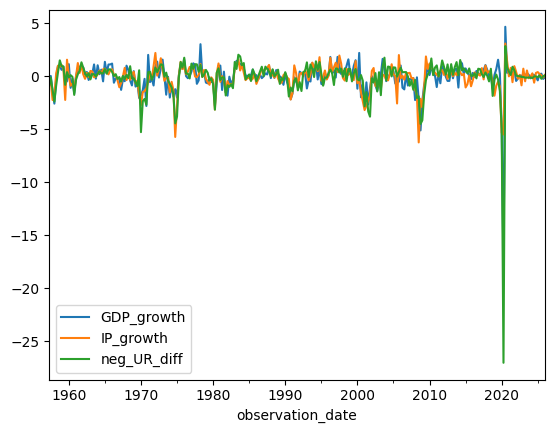

In [4]:
Y_std_mv.plot()

# Section 2: Models and Parameter Estimation

**Approach:** Use `MLEEstimator`, which wraps `scipy.optimize.minimize` in the *unconstrained* parameter
space. The model's `unconstrain_params` / `constrain_params` methods handle the reparameterization
(e.g. $\phi \mapsto \text{arctanh}(\phi)$, $\sigma^2 \mapsto \log\sigma^2$). Multiple random restarts
reduce the risk of converging to a local optimum.

**Fixing parameters:** `MLEEstimator.fit(fixed_params={'alpha': 1.0})` holds `alpha` at its
constrained value throughout optimization. Internally, `fit` operates over only the free-parameter
subspace and the stored `alpha` unconstrained coordinate is spliced back in before every likelihood
evaluation. Fixed parameters receive `NaN` standard errors in the summary.

**Standard errors** are computed via `mle_estimator.compute_std_errors()`, which applies the delta
method to a numerical Hessian over the *free* parameters only.

**Steps:**
1. Instantiate each model with reasonable initial parameters; call `.describe()` to confirm setup
2. Run `MLEEstimator.fit(fixed_params=...)` for each model; inspect convergence and log-likelihood
3. Compute and display standard errors via `.compute_std_errors()`
4. Plot the MLE parameter estimates across models

In [5]:
from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from models.linear_factor import MultivariateObservationLGSSM
from models.linear_macro import LinearMacroSSM
from estimation.mle_estimator import MLEResult, MLEEstimator

In [6]:
gdp_growth = Y_std_mv['GDP_growth'].values  # standardized GDP growth series as np array

SimpleLGSSM = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=1.0, tau2=0.5, seed=42)
print(SimpleLGSSM.describe())

mle_simple = MLEEstimator(
    model=SimpleLGSSM,
    data=gdp_growth,
    method="L-BFGS-B",
    n_restarts=20,
    restart_std=0.5,
    seed=10,
)

# alpha is fixed at 1 to resolve the scale weak-identifiability.
# SE for alpha will be NaN (it was not estimated).
result_simple = mle_simple.fit(fixed_params={'alpha': 1.0})
mle_simple.compute_std_errors()
print(result_simple.summary())

SimpleLinearGaussianSSM
  Simple linear Gaussian SSM — 1D latent state and observation
  Parameters: {'phi': 0.5, 'alpha': 1.0, 'sigma2': 1.0, 'tau2': 0.5}
  Transition:  x_t = 0.5 * x_(t-1) + eps_t,   eps_t ~ N(0, 1.0)
  Observation: y_t = 1.0 * x_t + nu_t,       nu_t  ~ N(0, 0.5)
  Initial:     x_0 ~ N(0, 1.33333)  [stationary]
Restart 10/20 best val: 503.4593443219751
MLEEstimator.fit  1.649s
MLEResult  loglik=-503.4593  converged  n_evals=92
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.328788      0.359022
  alpha                 1.000000             —
  sigma2                0.834832      1.201793
  tau2                  1.355570      1.110976


In [7]:
phi_s_hat, alpha_s_hat, sigma2_s_hat, tau2_s_hat = result_simple.constrained_params

## 2.2 Multivariate Observation LG-SSM

Fit a single latent business-cycle factor to all three standardized series jointly.
The identification constraint $\alpha^{(1)} \equiv 1$ is imposed by fixing `alpha_1 = 1`
(it is not a free parameter in `MultivariateObservationLGSSM`; see `linear_factor.py`).

Because the data are pre-standardized (zero mean, unit variance over the full sample),
the intercepts $\mu^{(k)}$ should be near zero. They are fixed at zero via `fixed_params`
below — this both enforces the constraint and keeps the parameter count at $3K - 1 = 8$
free parameters: $\phi$, $\sigma^2$, $\alpha_2$, $\alpha_3$, $\tau^2_1$, $\tau^2_2$, $\tau^2_3$.

> **[WARNING]** Fixing $\mu^{(k)} = 0$ is appropriate only when all series are
> standardized over the **full** sample (which introduces a look-ahead bias;
> see Section 1 warning). For rolling-window or out-of-sample evaluation, the
> intercepts should either be estimated or standardization should use only past data.

In [8]:
K = 3  # GDP growth, IP growth, -ΔUR

FactorLGSSM = MultivariateObservationLGSSM(
    phi=0.7,
    sigma2=0.5,
    alphas=[1.0, 0.8, 0.6],   # alpha_1 fixed at 1.0 by construction
    tau2s=[0.3, 0.4, 0.5],
    mus=None,                   # zeros; will be fixed at estimation time
    obs_names=list(Y_std_mv.columns),
    seed=42,
)
print(FactorLGSSM.describe())

mle_factor = MLEEstimator(
    model=FactorLGSSM,
    data=Y_arr_mv,
    method="L-BFGS-B",
    n_restarts=20,
    restart_std=0.5,
    seed=10,
)

# Fix intercepts at zero (data is pre-standardized; alpha_1 ≡ 1 is hard-coded).
fixed_mus = {f'mu_{k + 1}': 0.0 for k in range(K)}
result_factor = mle_factor.fit(fixed_params=fixed_mus)
mle_factor.compute_std_errors()
print(result_factor.summary())

MultivariateObservationLGSSM
  Multivariate-observation LG-SSM  (K=3 series, 1D latent factor)
  Transition:  x_t = 0.7 x_(t-1) + eps_t,  eps_t ~ N(0, 0.5)
  Initial:     x_0 ~ N(0, 0.9804)  [stationary]
  Observations (alpha^(1) = 1.0 fixed):
    GDP_growth: 1.0 [fixed] * x_t + nu^(1),  nu^(1) ~ N(0, 0.3)
    IP_growth: 0.8 * x_t + nu^(2),  nu^(2) ~ N(0, 0.4)
    neg_UR_diff: 0.6 * x_t + nu^(3),  nu^(3) ~ N(0, 0.5)
Restart 10/20 best val: 1243.751837348216
MLEEstimator.fit  43.254s
MLEResult  loglik=-1243.7518  converged  n_evals=224
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.252723      0.063483
  sigma2                1.833661      0.193630
  alpha_2               0.579852      0.041185
  alpha_3               1.312503      0.058988
  tau2_1                0.332369      0.066508
  tau2_2                0.699273      0.064610
  tau2_3                0.5

In [9]:
params_f = result_factor.constrained_params
phi_f_hat   = params_f[0]
sigma2_f_hat = params_f[1]
alpha2_f_hat, alpha3_f_hat = params_f[2], params_f[3]
tau2s_f_hat = params_f[4:7]   # tau2_1, tau2_2, tau2_3

## 2.3 Macro LG-SSM (HLW)

**Additional data required.** The HLW model needs four quarterly series in annualised
percent that are not all present in the Section 1 cache:

| Column | Series | Transform |
|---|---|---|
| `dY` | Real GDP growth | $400 \times \Delta \log \texttt{GDPC1}$ |
| `pi` | Core PCE inflation | $400 \times \Delta \log \texttt{PCEPILFE}$ |
| `u` | Unemployment rate | `UNRATE` quarterly average |
| `i` | Federal funds rate | `FEDFUNDS` quarterly average |

Using **1960 Q1 onwards** to avoid early postwar volatility.
The cell below checks for a local cache (`data/macro_lgssm.csv`) and downloads
the two missing series from FRED's public CSV endpoint if needed.

**Fixed parameters** (not estimated — see identification note in model description):

| Parameter | Value | Reason |
|---|---|---|
| $c_g$ | 1.0 | Growth loading on $r^*$; hard to identify jointly with $\sigma_g$ |
| $\sigma_g$ | 0.035 | Trend-growth volatility; calibrated (HLW convention) |
| $\sigma_\zeta$ | 0.35 | Non-growth $r^*$ volatility; calibrated |
| $\pi^*$ | 2.0 | Fed inflation target (pp annualised) |

> **[USER CLARIFICATION NEEDED]** The fixed values for $\sigma_g$, $\sigma_\zeta$,
> and $c_g$ follow HLW conventions but can be changed. Alternatively, all three can
> be freed and estimated via a concentrated-likelihood approach (HLW Stage 2/3), at
> the cost of much longer run times and noisier estimates.

In [10]:
import requests, io
from models.linear_macro import LinearMacroSSM

_MACRO_CACHE = DATA_DIR / 'macro_lgssm.csv'

def _fetch_fred(series_id):
    """Download a single FRED series via the public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text),
                     parse_dates=['observation_date'],
                     index_col='observation_date')
    return pd.to_numeric(df.iloc[:, 0], errors='coerce').rename(series_id)

if _MACRO_CACHE.exists():
    Y_macro = pd.read_csv(_MACRO_CACHE, index_col='observation_date', parse_dates=True)
    print("Loaded from cache.")
else:
    print("Downloading PCEPILFE and FEDFUNDS from FRED …")
    pce = _fetch_fred('PCEPILFE')   # monthly core PCE price index
    ffr = _fetch_fred('FEDFUNDS')   # monthly federal funds rate

    gdpc1    = _raw['GDPC1']
    unrate_q = _raw['UNRATE'].resample('QS').mean()   # quarter-average
    pce_q    = pce.resample('QS').last()               # quarter-end level
    ffr_q    = ffr.resample('QS').mean()               # quarter-average

    dY = (400 * np.log(gdpc1).diff()).rename('dY')       # annualised quarterly GDP growth (%)
    pi = (400 * np.log(pce_q).diff()).rename('pi')        # annualised quarterly PCE inflation (%)

    Y_macro = pd.concat(
        [dY, pi, unrate_q.rename('u'), ffr_q.rename('i')],
        axis=1, join='inner'
    ).dropna()
    Y_macro = Y_macro[Y_macro.index >= '1960-01-01']
    Y_macro.to_csv(_MACRO_CACHE)
    print(f"Saved to {_MACRO_CACHE}.")

Y_arr_macro = Y_macro.values
T_macro     = len(Y_arr_macro)
dates_macro = Y_macro.index

print(f"\nShape: {Y_arr_macro.shape}  ({T_macro} quarters)")
print(f"Range: {dates_macro[0].date()} → {dates_macro[-1].date()}")
print()
print(Y_macro.describe().round(2))

Loaded from cache.

Shape: (265, 4)  (265 quarters)
Range: 1960-01-01 → 2026-01-01

           dY      pi       u       i
count  265.00  265.00  265.00  265.00
mean     2.94    3.17    5.84    4.79
std      4.22    2.13    1.66    3.59
min    -32.82   -1.05    3.40    0.06
25%      1.39    1.66    4.60    2.00
50%      3.04    2.52    5.60    4.73
75%      4.51    4.40    6.90    6.47
max     29.90   10.94   11.00   17.78


In [11]:
# ── Initial parameter values (HLW-calibrated) ────────────────────────────────
# sigma_g, sigma_zeta, c_g are fixed below; pi_star is fixed in the constructor.
MacroSSM = LinearMacroSSM(
    phi_1=1.52,  phi_2=-0.54,   # IS-curve AR(2): typical HLW estimates; |φ₁+φ₂| < 1 ✓
    lambda_r=-0.05,              # real-rate-gap sensitivity (must be < 0)
    c_g=1.0,                     # fixed: growth loading on r*
    alpha_pi=0.35,               # inflation persistence in Phillips curve
    beta_pi=0.35,                # unemployment-gap → inflation sensitivity
    gamma=0.40,                  # Okun output-gap coefficient
    rho_i=0.75,                  # Taylor-rule inertia
    psi_pi=1.50,                 # Taylor inflation response (> 1: Taylor principle)
    psi_x=0.10,                  # Taylor output-gap response
    sigma_x=0.80,                # output-gap shock SD
    sigma_g=0.035,               # fixed: trend-growth shock SD (HLW calibrated)
    sigma_zeta=0.35,             # fixed: non-growth r* shock SD (HLW calibrated)
    sigma_u_star=0.10,           # NAIRU shock SD
    sigma_dY=0.70,               # GDP-growth observation noise SD
    sigma_pi=1.00,               # inflation observation noise SD
    sigma_u=0.30,                # unemployment observation noise SD
    sigma_i=0.50,                # interest-rate observation noise SD
    pi_star=2.0,                 # fixed: Fed inflation target (% annualised)
    diffuse_var=1e4,             # diffuse prior variance for all state components
    seed=42,
)
print(MacroSSM.describe())
print()

# Sanity-check: log-likelihood at the initial values
ll0 = MacroSSM.log_likelihood(Y_arr_macro)
print(f"log_likelihood at initial params: {ll0:.2f}  (T={T_macro})")

LinearMacroSSM  (HLW macro state-space model)
  State (8D): [x_t, x_{t-1}, g_t*, zeta_t, r_t*, r*_{t-1}, u_t*, u*_{t-1}]
  Obs   (4D): [DeltaY_t, pi_t, u_t, i_t]

  IS curve:   phi_1=1.52, phi_2=-0.54, lambda_r=-0.05
  Neutral r*: c_g=1
  Phillips:   alpha_pi=0.35, beta_pi=0.35
  Okun:       gamma=0.4
  Taylor:     rho_i=0.75, psi_pi=1.5, psi_x=0.1,  pi*=2 (fixed)

  Latent noise SDs:  sigma_x=0.8, sigma_g=0.035, sigma_zeta=0.35, sigma_u*=0.1
  Obs noise SDs:     sigma_dY=0.7, sigma_pi=1, sigma_u=0.3, sigma_i=0.5

log_likelihood at initial params: -3593.94  (T=265)


In [12]:
# ── MLE estimation ────────────────────────────────────────────────────────────
# Fix the three weakly-identified parameters; estimate the remaining 15 freely.
# n_restarts=10 gives a reasonable coverage of the likelihood surface;
# increase to 20–50 for production use (run time scales linearly).
_fixed_macro = {
    'c_g':        1.0,    # growth loading on r* (see identification note)
    'sigma_g':    0.035,  # trend-growth volatility (HLW calibrated)
    'sigma_zeta': 0.35,   # non-growth r* volatility (HLW calibrated)
}

mle_macro = MLEEstimator(
    model=MacroSSM,
    data=Y_arr_macro,
    method='L-BFGS-B',
    n_restarts=10,
    restart_std=0.5,
    seed=42,
)

result_macro = mle_macro.fit(fixed_params=_fixed_macro)
mle_macro.compute_std_errors()
print(result_macro.summary())

MLEEstimator.fit  628.271s
MLEResult  loglik=-1568.8293  converged  n_evals=4624
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi_1                 1.006892      0.072016
  phi_2                -0.079059      0.074274
  lambda_r             -0.131328      0.176427
  c_g                   1.000000             —
  alpha_pi              0.509494      0.060609
  beta_pi               0.009109      0.016164
  gamma                 0.141052      0.010859
  rho_i                 0.832970      0.040400
  psi_pi                1.000001      0.000155
  psi_x                 0.278143      0.063734
  sigma_x               3.587129      0.228983
  sigma_g               0.035000             —
  sigma_zeta            0.350000             —
  sigma_u_star          0.234332      0.043953
  sigma_dY              1.916221      0.257511
  sigma_pi              1.042467      0.045363
  sigma_u        

In [13]:
# ── Unpack MLE estimates ──────────────────────────────────────────────────────
_p = result_macro.constrained_params
(phi_1_hat, phi_2_hat, lambda_r_hat, c_g_hat,
 alpha_pi_hat, beta_pi_hat,
 gamma_hat,
 rho_i_hat, psi_pi_hat, psi_x_hat,
 sigma_x_hat, sigma_g_hat, sigma_zeta_hat, sigma_u_star_hat,
 sigma_dY_hat, sigma_pi_hat, sigma_u_hat, sigma_i_hat) = _p

print("Key structural parameter estimates:")
print(f"  IS curve:    phi_1={phi_1_hat:.4f}, phi_2={phi_2_hat:.4f}, lambda_r={lambda_r_hat:.4f}")
print(f"  Neutral r*:  c_g={c_g_hat:.4f}  [fixed]")
print(f"  Phillips:    alpha_pi={alpha_pi_hat:.4f}, beta_pi={beta_pi_hat:.4f}")
print(f"  Okun:        gamma={gamma_hat:.4f}")
print(f"  Taylor:      rho_i={rho_i_hat:.4f}, psi_pi={psi_pi_hat:.4f}, psi_x={psi_x_hat:.4f}")

Key structural parameter estimates:
  IS curve:    phi_1=1.0069, phi_2=-0.0791, lambda_r=-0.1313
  Neutral r*:  c_g=1.0000  [fixed]
  Phillips:    alpha_pi=0.5095, beta_pi=0.0091
  Okun:        gamma=0.1411
  Taylor:      rho_i=0.8330, psi_pi=1.0000, psi_x=0.2781


## 2.4 Free Linear Gaussian SSM

A fully unconstrained LG-SSM where **all matrix entries are free parameters** (subject only to
structural requirements). The user specifies the latent dimension `N_LATENT`.

**Observations (5D):** HLW panel plus industrial production growth.

| Column | Series | Transform |
|---|---|---|
| `dY` | Real GDP growth | $400 \times \Delta \log \texttt{GDPC1}$ (% ann.) |
| `pi` | Core PCE inflation | $400 \times \Delta \log \texttt{PCEPILFE}$ (% ann.) |
| `ip` | IP growth | $100 \times \Delta \log \texttt{INDPRO}$, quarterly (%) |
| `u` | Unemployment rate | `UNRATE` quarterly average (%) |
| `i` | Federal funds rate | `FEDFUNDS` quarterly average (%) |

**Parametrization** (see `FreeLinearGaussianSSM` in `src/models/linear_gaussian.py`):
- $A$: lower triangular; diagonal entries $\in(-1,1)$ via $\tanh$ → spectral radius $< 1$ guaranteed
- $Q = L L^\top$, $L$ lower triangular with positive diagonal (Cholesky)
- $C$: free $m \times n$ matrix
- $R = \operatorname{diag}(\sigma_1^2, \ldots, \sigma_m^2)$, log-variance transform
- $b, d$: unconstrained intercepts

**Total free parameters:** $n(n+1) + mn + 2m + n$ (e.g. 28 for $n=2$, 40 for $n=3$).

> **Identification warning.** Latent states are identified only up to an invertible linear
> transformation. MLE with multiple restarts will often converge to different solutions
> with nearly identical log-likelihoods — this is expected, not a bug.

In [14]:
# ── Build 5-column observation matrix: HLW panel + quarterly IP growth ────────
indpro_q    = _raw['INDPRO'].resample('QS').last()
ip_growth_q = (100 * np.log(indpro_q).diff()).rename('ip')

Y_free = Y_macro.join(ip_growth_q, how='left')
Y_free = Y_free.reindex(columns=['dY', 'pi', 'ip', 'u', 'i'])
Y_free['ip'] = Y_free['ip'].ffill()
Y_free = Y_free.dropna()

Y_arr_free = Y_free.values
T_free     = len(Y_arr_free)
dates_free = Y_free.index

print(f"Free-model data: {Y_arr_free.shape}  ({T_free} quarters)")
print(f"Range: {dates_free[0].date()} → {dates_free[-1].date()}")
print()
print(Y_free.describe().round(2))

Free-model data: (265, 5)  (265 quarters)
Range: 1960-01-01 → 2026-01-01

           dY      pi      ip       u       i
count  265.00  265.00  265.00  265.00  265.00
mean     2.94    3.17    0.55    5.84    4.79
std      4.22    2.13    1.69    1.66    3.59
min    -32.82   -1.05   -7.30    3.40    0.06
25%      1.39    1.66   -0.06    4.60    2.00
50%      3.04    2.52    0.70    5.60    4.73
75%      4.51    4.40    1.51    6.90    6.47
max     29.90   10.94    4.95   11.00   17.78


In [15]:
from models.linear_gaussian import FreeLinearGaussianSSM

N_LATENT = 3   # ← change to experiment with different latent dimensions
N_OBS    = 5   # fixed: [dY, pi, ip, u, i]

FreeLGSSM = FreeLinearGaussianSSM(
    n_latent=N_LATENT,
    n_obs=N_OBS,
    seed=42,
)
print(FreeLGSSM.describe())
print(f"\nlog-likelihood at initial params: {FreeLGSSM.log_likelihood(Y_arr_free):.2f}  (T={T_free})")
print(f"Total free params: {len(FreeLGSSM.params_dict)}")

FreeLinearGaussianSSM
  n_latent=3, n_obs=5,  total free params=40
  A lower triangular, spectral radius=0.5000
  Q = L L^T  (Cholesky;  L lower triangular)
  R = diag([1.0, 1.0, 1.0, 1.0, 1.0])
  b=[0.0, 0.0, 0.0],  d=[0.0, 0.0, 0.0, 0.0, 0.0]
  Initial: x_0 ~ N(mu_0, P_0)  [stationary]

log-likelihood at initial params: -16458.76  (T=265)
Total free params: 40


In [16]:
mle_free = MLEEstimator(
    model=FreeLGSSM,
    data=Y_arr_free,
    method='L-BFGS-B',
    n_restarts=10,
    restart_std=0.5,
    seed=42,
)

result_free = mle_free.fit()
mle_free.compute_std_errors()
print(result_free.summary())

MLEEstimator.fit  1581.092s
MLEResult  loglik=-2070.4311  NOT CONVERGED  n_evals=15006
  STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

  Parameter             Estimate     Std error
  --------------------------------------------
  A_00                  0.907269      0.058069
  A_10                 -0.030545      0.404469
  A_11                  0.956935      0.035807
  A_20                 -0.568996      4.478961
  A_21                  0.116742      3.310219
  A_22                  0.193300      0.088745
  L_00                  0.473114      1.438230
  L_10                 -0.412674             —
  L_11                  0.345725      1.381529
  L_20                  1.533777      2.315912
  L_21                  0.659966      2.264389
  L_22                  0.702886      0.186610
  C_00                 -0.097039      7.729001
  C_01                  0.566353      7.542424
  C_02                 -1.924976      0.301902
  C_10                  0.080070      2.017255
  C_11         

# Section 3: Filtering and Smoothing

Given the MLE point estimates $\hat\theta$, recover the filtered and smoothed distributions
over the latent state $x_t$.

**Kalman filter** (exact, for all LG-SSMs):
- Forward pass: computes $p(x_t \mid y_{1:t}, \hat\theta)$ — the **filtered** distribution — as a sequence of Gaussians $(m_{t|t}, P_{t|t})$.
- Filtered mean $m_{t|t}$ is the minimum-variance real-time estimate of the business cycle.
- Uses `KalmanFilter` from `src/estimation/kalman_filter.py`.

**RTS smoother** (exact, for all LG-SSMs):
- Backward pass on top of the Kalman filter: computes $p(x_t \mid y_{1:T}, \hat\theta)$ — the **smoothed** distribution.
- Smoothed mean $m_{t|T}$ uses all observations (past and future) and is typically tighter than the filtered mean.

**Particle filter** (approximate, for comparison):
- Bootstrap particle filter using `ParticleFilter` from `src/estimation/particle_filter.py`.
- Useful as a sanity check: for LG-SSMs the particle filter should converge to the Kalman filter as the number of particles $N \to \infty$.
- Also serves as the template for non-linear/non-Gaussian extensions.

**Steps:**
1. Run Kalman filter with MLE parameters for each model; plot filtered means with 95% credible bands
2. Run RTS smoother; overlay smoothed means
3. (Optional) Run particle filter with $N = 500, 2000$ particles; compare to Kalman output

In [17]:
from estimation.kalman_filter import KalmanFilter

model_simple_fitted = SimpleLinearGaussianSSM(phi_s_hat, alpha_s_hat, sigma2_s_hat, tau2_s_hat, seed = 42)
kalman_simple = KalmanFilter(model_simple_fitted, gdp_growth)
filtered_means, filtered_covs, loglik = kalman_simple.run_filter()
smoothed_means, smoothed_covs = kalman_simple.run_smoother()

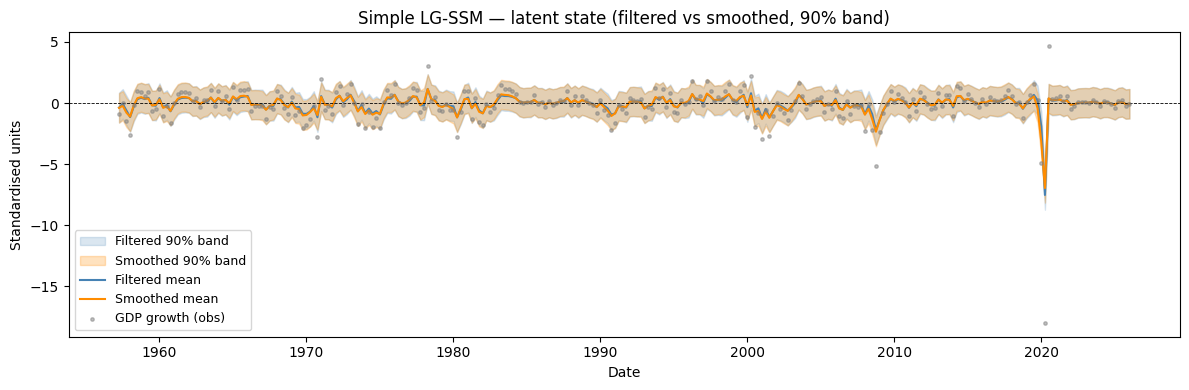

In [18]:
z90 = 1.645  # 90% credible band multiplier

filt_m_s = filtered_means[:, 0]
filt_sd_s = np.sqrt(filtered_covs[:, 0, 0])
sm_m_s    = smoothed_means[:, 0]
sm_sd_s   = np.sqrt(smoothed_covs[:, 0, 0])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dates_mv, filt_m_s - z90 * filt_sd_s, filt_m_s + z90 * filt_sd_s,
                alpha=0.20, color='steelblue', label='Filtered 90% band')
ax.fill_between(dates_mv, sm_m_s - z90 * sm_sd_s, sm_m_s + z90 * sm_sd_s,
                alpha=0.25, color='darkorange', label='Smoothed 90% band')
ax.plot(dates_mv, filt_m_s, color='steelblue', lw=1.5, label='Filtered mean')
ax.plot(dates_mv, sm_m_s,   color='darkorange', lw=1.5, label='Smoothed mean')
ax.scatter(dates_mv, gdp_growth, s=6, color='gray', alpha=0.5, zorder=5, label='GDP growth (obs)')
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_title('Simple LG-SSM — latent state (filtered vs smoothed, 90% band)')
ax.set_xlabel('Date')
ax.set_ylabel('Standardised units')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3.2 Multivariate Observation LG-SSM

Run the Kalman filter and RTS smoother on the three-series panel using the MLE factor model.
The single latent factor $x_t$ is the minimum-variance estimate of the common business cycle.

In [19]:
FactorLGSSM_fitted = MultivariateObservationLGSSM(
    phi=phi_f_hat,
    sigma2=sigma2_f_hat,
    alphas=[1.0, alpha2_f_hat, alpha3_f_hat],
    tau2s=list(tau2s_f_hat),
    mus=None,
    obs_names=list(Y_std_mv.columns),
    seed=42,
)

kf_factor = KalmanFilter(FactorLGSSM_fitted, Y_arr_mv)
fm_factor, fP_factor, ll_factor = kf_factor.run_filter()
sm_factor, sP_factor = kf_factor.run_smoother()

print(f"Factor LG-SSM log-likelihood (MLE params): {ll_factor:.4f}")
print(f"Filtered state range:  [{fm_factor[:, 0].min():.3f}, {fm_factor[:, 0].max():.3f}]")
print(f"Smoothed state range:  [{sm_factor[:, 0].min():.3f}, {sm_factor[:, 0].max():.3f}]")

Factor LG-SSM log-likelihood (MLE params): -1243.7518
Filtered state range:  [-17.330, 2.906]
Smoothed state range:  [-17.193, 2.904]


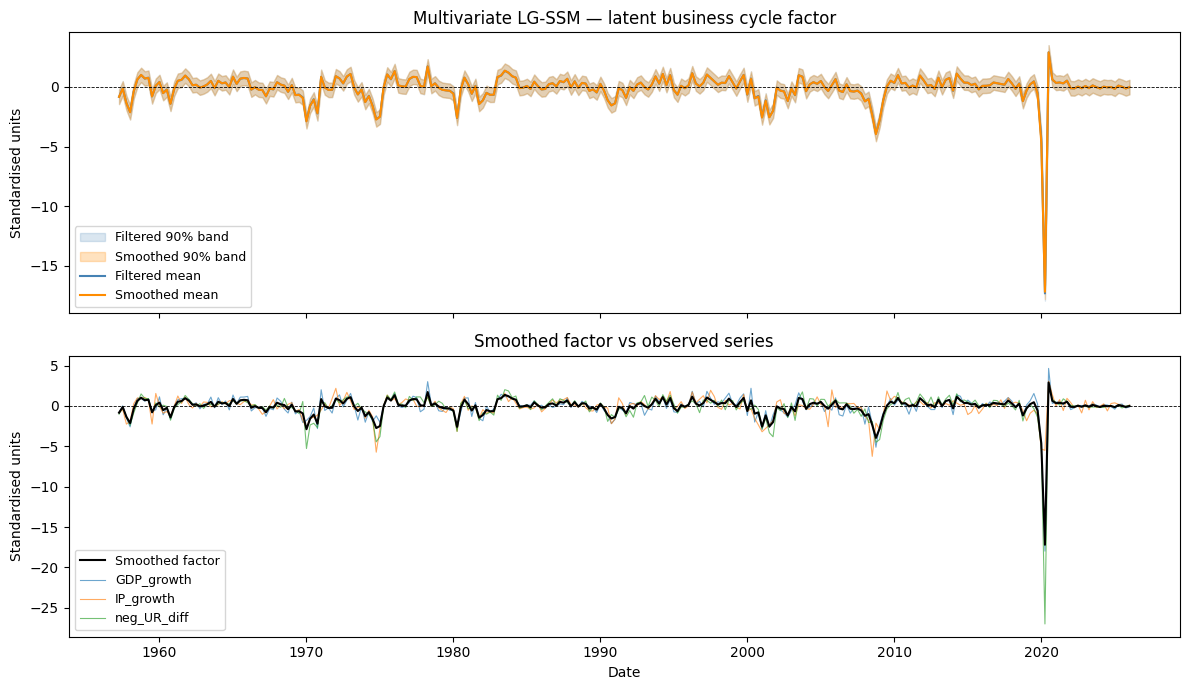

In [20]:
filt_m_f  = fm_factor[:, 0]
filt_sd_f = np.sqrt(fP_factor[:, 0, 0])
sm_m_f    = sm_factor[:, 0]
sm_sd_f   = np.sqrt(sP_factor[:, 0, 0])

obs_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: latent business cycle factor
ax = axes[0]
ax.fill_between(dates_mv, filt_m_f - z90 * filt_sd_f, filt_m_f + z90 * filt_sd_f,
                alpha=0.20, color='steelblue', label='Filtered 90% band')
ax.fill_between(dates_mv, sm_m_f - z90 * sm_sd_f, sm_m_f + z90 * sm_sd_f,
                alpha=0.25, color='darkorange', label='Smoothed 90% band')
ax.plot(dates_mv, filt_m_f, color='steelblue', lw=1.5, label='Filtered mean')
ax.plot(dates_mv, sm_m_f,   color='darkorange', lw=1.5, label='Smoothed mean')
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_title('Multivariate LG-SSM — latent business cycle factor')
ax.set_ylabel('Standardised units')
ax.legend(fontsize=9)

# Bottom: observed series overlaid on smoothed factor
ax = axes[1]
ax.plot(dates_mv, sm_m_f, color='black', lw=1.5, label='Smoothed factor', zorder=5)
for k, col in enumerate(Y_std_mv.columns):
    ax.plot(dates_mv, Y_arr_mv[:, k], lw=0.8, alpha=0.65,
            color=obs_colors[k], label=col)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_title('Smoothed factor vs observed series')
ax.set_xlabel('Date')
ax.set_ylabel('Standardised units')
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 3.3 Macro LG-SSM (HLW)

Run the RTS smoother (which internally runs the Kalman filter) on the macro panel using the MLE
estimates. The 8D state is smoothed; we plot the four economically interpretable components:

| State | Index | Interpretation |
|---|---|---|
| $x_t$ | 0 | Output gap (% potential GDP) |
| $g_t^*$ | 2 | Trend (potential) growth (% ann.) |
| $r_t^*$ | 4 | Neutral real interest rate (% ann.) |
| $u_t^*$ | 6 | NAIRU (%) |

Because the prior is diffuse ($P_0 = 10^4 \cdot I$), the first ~10 quarters of filtered/smoothed
estimates are dominated by prior uncertainty and should be interpreted with caution.

In [21]:
MacroSSM_fitted = LinearMacroSSM(
    phi_1=phi_1_hat, phi_2=phi_2_hat, lambda_r=lambda_r_hat,
    c_g=c_g_hat,
    alpha_pi=alpha_pi_hat, beta_pi=beta_pi_hat,
    gamma=gamma_hat,
    rho_i=rho_i_hat, psi_pi=psi_pi_hat, psi_x=psi_x_hat,
    sigma_x=sigma_x_hat, sigma_g=sigma_g_hat, sigma_zeta=sigma_zeta_hat,
    sigma_u_star=sigma_u_star_hat,
    sigma_dY=sigma_dY_hat, sigma_pi=sigma_pi_hat,
    sigma_u=sigma_u_hat, sigma_i=sigma_i_hat,
    pi_star=2.0, diffuse_var=1e4, seed=42,
)

# smoother() runs the Kalman filter internally and returns both
sm_macro, smP_macro, fm_macro, fmP_macro, ll_macro_sm = MacroSSM_fitted.smoother(Y_arr_macro)

print(f"Macro LG-SSM log-likelihood: {ll_macro_sm:.2f}")
print(f"Smoothed output gap range:   [{sm_macro[:, 0].min():.2f}, {sm_macro[:, 0].max():.2f}] pp")
print(f"Smoothed neutral rate range: [{sm_macro[:, 4].min():.2f}, {sm_macro[:, 4].max():.2f}] % ann.")

Macro LG-SSM log-likelihood: -1568.83
Smoothed output gap range:   [-37.51, 12.38] pp
Smoothed neutral rate range: [-0.33, 4.74] % ann.


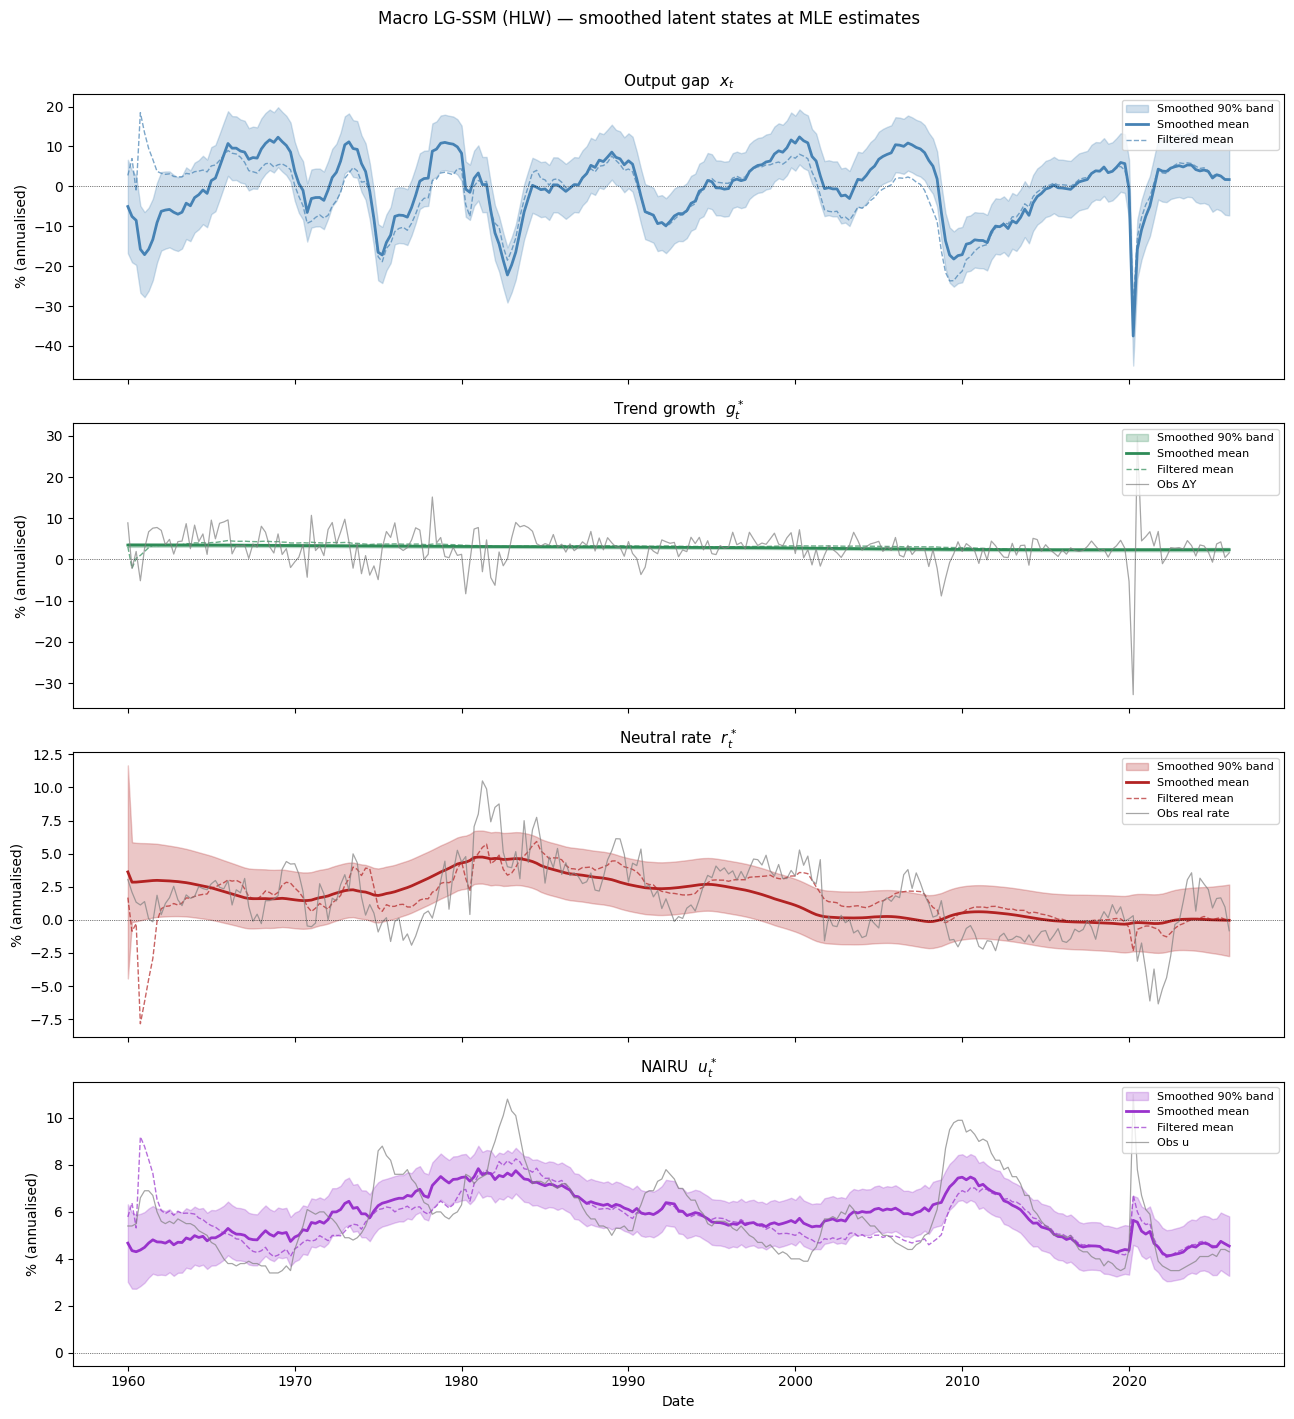

In [22]:
_S_X, _S_G, _S_R, _S_U = 0, 2, 4, 6   # state indices for key components

_states = [
    (_S_X, 'Output gap  $x_t$',          'steelblue',   None,              None),
    (_S_G, 'Trend growth  $g_t^*$',       'seagreen',    Y_macro['dY'],     'Obs ΔY'),
    (_S_R, 'Neutral rate  $r_t^*$',       'firebrick',   Y_macro['i'] - Y_macro['pi'], 'Obs real rate'),
    (_S_U, 'NAIRU  $u_t^*$',              'darkorchid',  Y_macro['u'],      'Obs u'),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

for ax, (idx, title, color, obs_series, obs_label) in zip(axes, _states):
    sm_mean = sm_macro[:, idx]
    sm_sd   = np.sqrt(np.abs(smP_macro[:, idx, idx]))   # abs guards tiny negatives
    fm_mean = fm_macro[:, idx]

    ax.fill_between(dates_macro,
                    sm_mean - z90 * sm_sd, sm_mean + z90 * sm_sd,
                    alpha=0.25, color=color, label='Smoothed 90% band')
    ax.plot(dates_macro, sm_mean, color=color, lw=2.0, label='Smoothed mean')
    ax.plot(dates_macro, fm_mean, color=color, lw=1.0, ls='--', alpha=0.7, label='Filtered mean')

    if obs_series is not None:
        ax.plot(dates_macro, obs_series.values, color='gray', lw=0.9, alpha=0.7, label=obs_label)

    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('% (annualised)')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
fig.suptitle('Macro LG-SSM (HLW) — smoothed latent states at MLE estimates', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 3.4 Free Linear Gaussian SSM

Kalman filter and RTS smoother for the free LG-SSM at its MLE estimates.
The `N_LATENT` latent dimensions carry no pre-assigned economic interpretation —
they are the low-dimensional projection that best explains the 5-series panel in
a least-squares-Gaussian sense. Different random restarts may yield rotated but
equally valid latent representations.

In [23]:
kf_free = KalmanFilter(FreeLGSSM, Y_arr_free)
fm_free, fP_free, ll_free_kf = kf_free.run_filter()
sm_free, sP_free = kf_free.run_smoother()

print(f"Free LG-SSM log-likelihood (MLE): {ll_free_kf:.4f}")
for k in range(N_LATENT):
    print(f"  Component {k+1}:  filtered range [{fm_free[:,k].min():.2f}, {fm_free[:,k].max():.2f}]"
          f"  smoothed range [{sm_free[:,k].min():.2f}, {sm_free[:,k].max():.2f}]")

Free LG-SSM log-likelihood (MLE): -2070.4311
  Component 1:  filtered range [-2.08, 5.33]  smoothed range [-2.07, 5.30]
  Component 2:  filtered range [0.30, 12.01]  smoothed range [0.32, 12.01]
  Component 3:  filtered range [-12.22, 16.29]  smoothed range [-12.18, 15.98]


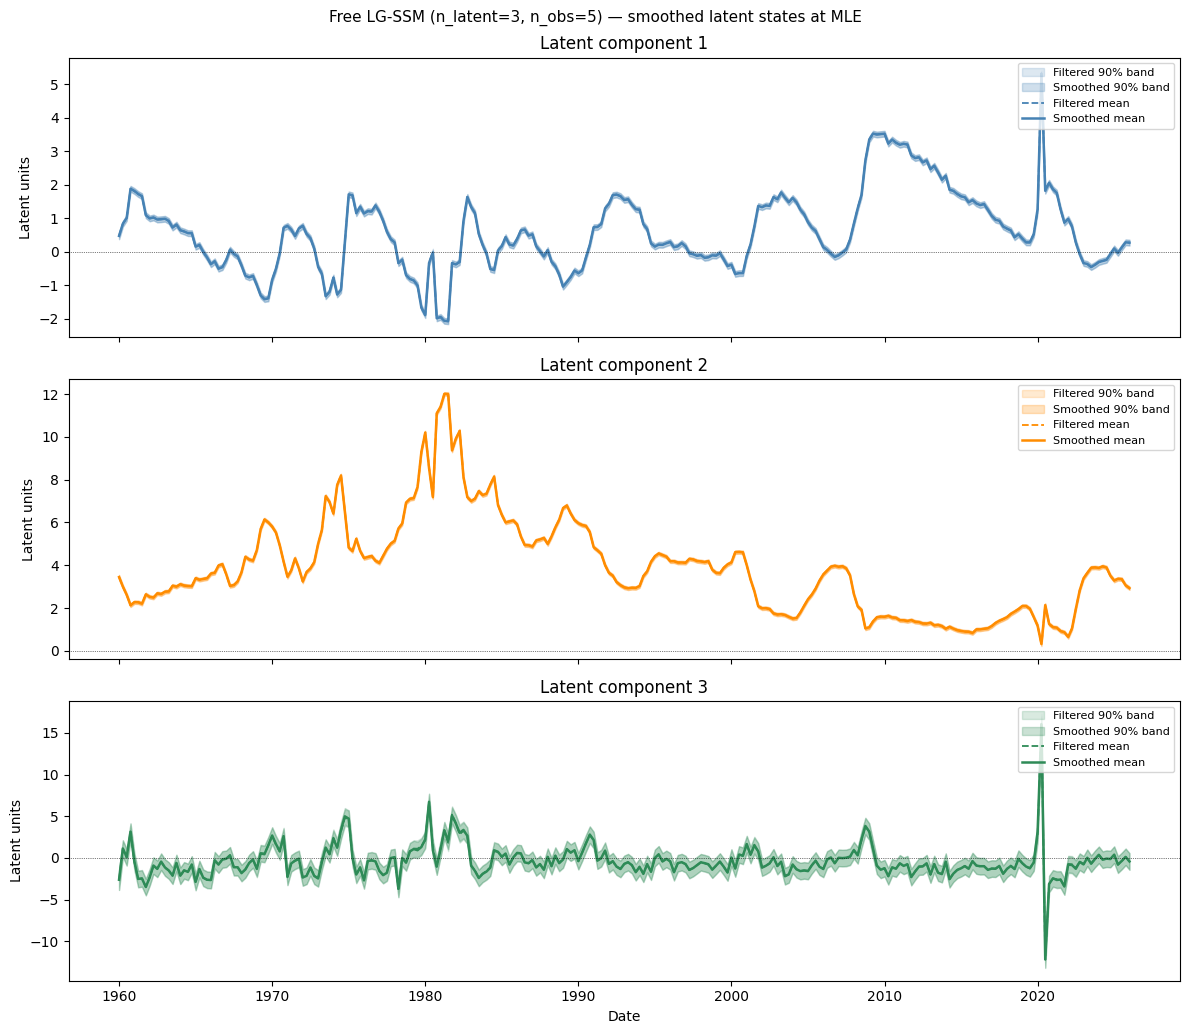

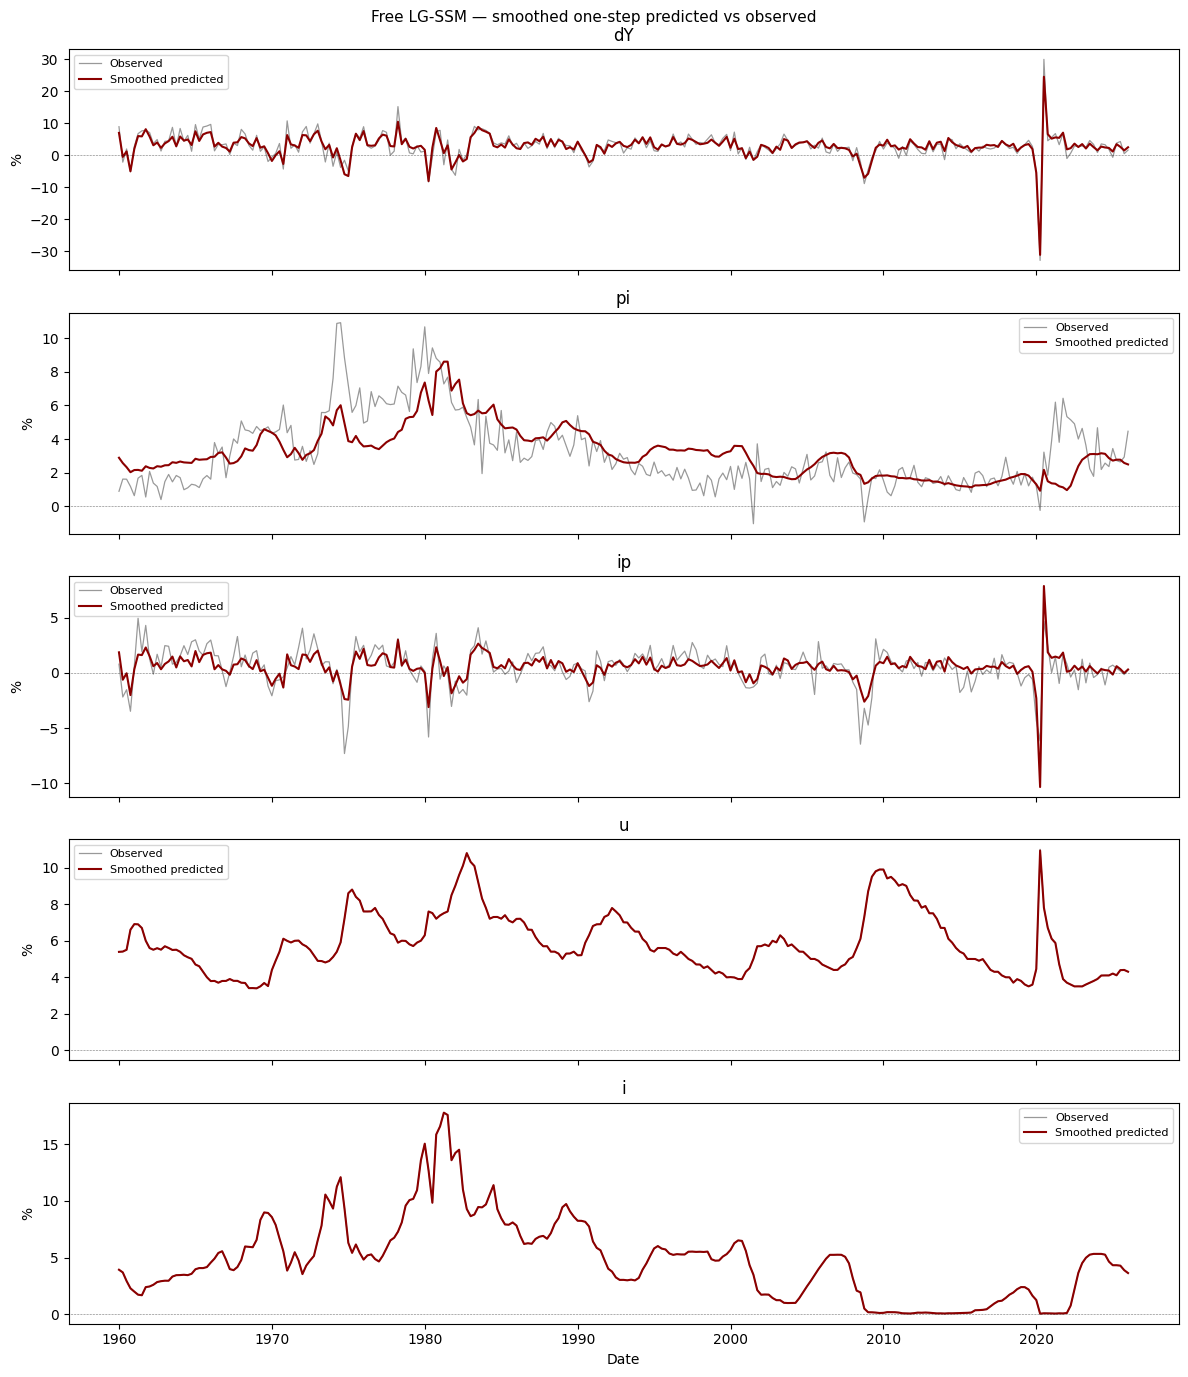

In [24]:
obs_cols = list(Y_free.columns)   # ['dY', 'pi', 'ip', 'u', 'i']

fig, axes = plt.subplots(N_LATENT, 1, figsize=(12, 3.5 * N_LATENT), sharex=True)
if N_LATENT == 1:
    axes = [axes]

latent_colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick', 'darkorchid']

for k, ax in enumerate(axes):
    color  = latent_colors[k % len(latent_colors)]
    fm_k   = fm_free[:, k]
    fsd_k  = np.sqrt(np.abs(fP_free[:, k, k]))
    sm_k   = sm_free[:, k]
    ssd_k  = np.sqrt(np.abs(sP_free[:, k, k]))

    ax.fill_between(dates_free, fm_k - z90 * fsd_k, fm_k + z90 * fsd_k,
                    alpha=0.18, color=color, label='Filtered 90% band')
    ax.fill_between(dates_free, sm_k - z90 * ssd_k, sm_k + z90 * ssd_k,
                    alpha=0.25, color=color, label='Smoothed 90% band')
    ax.plot(dates_free, fm_k, color=color, lw=1.3, ls='--', label='Filtered mean')
    ax.plot(dates_free, sm_k, color=color, lw=1.8, label='Smoothed mean')
    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_title(f'Latent component {k + 1}')
    ax.set_ylabel('Latent units')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
fig.suptitle(
    f'Free LG-SSM (n_latent={N_LATENT}, n_obs={N_OBS}) — smoothed latent states at MLE',
    fontsize=11
)
fig.tight_layout()
plt.show()

# ── Observation fit: smoothed predictions vs actuals ─────────────────────────
C_hat = FreeLGSSM.C   # (m, n)  observation matrix at MLE
d_hat = FreeLGSSM.d   # (m,)   observation intercept at MLE

# Predicted observations from smoothed states
Y_pred_sm = sm_free @ C_hat.T + d_hat   # (T, m)

fig2, axes2 = plt.subplots(N_OBS, 1, figsize=(12, 2.8 * N_OBS), sharex=True)
for k, ax in enumerate(axes2):
    ax.plot(dates_free, Y_arr_free[:, k], color='gray',  lw=0.9, alpha=0.8, label='Observed')
    ax.plot(dates_free, Y_pred_sm[:, k],  color='darkred', lw=1.5, label='Smoothed predicted')
    ax.axhline(0, color='black', lw=0.4, ls=':')
    ax.set_title(obs_cols[k])
    ax.set_ylabel('%')
    ax.legend(fontsize=8)

axes2[-1].set_xlabel('Date')
fig2.suptitle('Free LG-SSM — smoothed one-step predicted vs observed', fontsize=11)
fig2.tight_layout()
plt.show()

# Section 4: Prediction and Error Analysis

Evaluate one-step-ahead (and multi-step-ahead) predictive performance of each fitted model.

**One-step-ahead prediction** (from the Kalman filter innovation sequence):
- The Kalman filter produces innovations $v_t = y_t - C \hat m_{t|t-1}$ and innovation variances $S_t$.
- One-step-ahead predictive log-likelihood is already accumulated during `log_likelihood()`; the innovation sequence gives pointwise contributions.
- Root mean squared error (RMSE) of one-step-ahead predictions vs. realized observations.

**Multi-step-ahead prediction** (if applicable):
- Iterate the transition equation forward from $\hat m_{t|t}$; uncertainty grows as $\phi^{2h} \cdot P_{t|t} + \sum_{j=0}^{h-1} \phi^{2j} \sigma^2$.

> **[USER CLARIFICATION NEEDED]** What horizon(s) should multi-step prediction cover? Common choices
> for quarterly macro data are $h = 1, 2, 4$ quarters. Also: should predictions be made from a rolling
> or expanding estimation window (pseudo-out-of-sample), or from the in-sample MLE fit only?

**Steps:**
1. Extract and plot the one-step-ahead forecast errors (innovations) over time
2. Compute RMSE and log-score for each model across the full sample
3. Compare predictive performance across the Simple LG-SSM and Multivariate Observation LG-SSM